# load and inspect

In [1]:
import pandas as pd
import numpy as np


In [3]:
df=pd.read_csv("../Data/Telco-Customer-Churn.csv")

In [8]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df["Churn"].value_counts(normalize=True))

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

# Fixed data types and missing values

In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df[df["TotalCharges"].isnull()][["tenure", "MonthlyCharges", "TotalCharges"]]
df["TotalCharges"] = df["TotalCharges"].fillna(df["MonthlyCharges"])
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})


# EDA

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64


C:\Users\hp\AppData\Local\Temp\ipykernel_18500\2018881937.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tenure = df.groupby("tenure_bucket")["Churn"].mean()


PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: Churn, dtype: float64

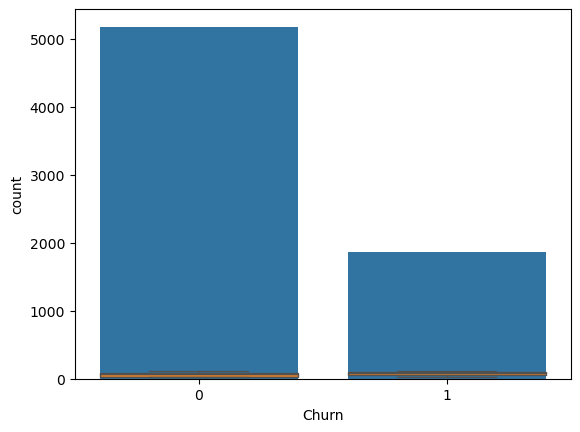

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Overall churn rate
sns.countplot(data=df, x="Churn")

# 2. Churn by contract type — usually the single strongest driver
churn_by_contract = df.groupby("Contract")["Churn"].mean().sort_values(ascending=False)
print(churn_by_contract)

# 3. Churn by tenure bucket
df["tenure_bucket"] = pd.cut(df["tenure"], bins=[0,12,24,48,60,72],
labels=["0-12","13-24","25-48","49-60","61-72"])
churn_by_tenure = df.groupby("tenure_bucket")["Churn"].mean()

# 4. Churn by monthly charges (are expensive customers churning more?)
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

# 5. Churn by internet service type / payment method
df.groupby("PaymentMethod")["Churn"].mean().sort_values(ascending=False)


In [11]:
df.to_csv("../Data/Telco_Customer_Churn_processed.csv", index=False)